Code to set path root

In [1]:
import sys
import os
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)


sys.path.append(os.path.abspath(".."))

# Training model on `fight-weaponized-other-dataset` with 64x64 Image Sizes
* using `datasets`, `transforms` module from `torchvison`
* using `dataloader` module from `torch.utils.data`

## Importing necessary Modules

In [2]:
# Import torch libraries
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn

# Import modules
from modules.architectures.Architecture import Architecture, ResidualBlock
from modules.helper.Trainer import Trainer
from modules.helper.Plotter import plot_training_metrics, plot_testing_history
from modules.helper.Tester import  Tester

Check if CUDA is used

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Device count:", torch.cuda.device_count())
else:
    print("Running on CPU")

CUDA available: True
CUDA device name: NVIDIA GeForce RTX 4070 Laptop GPU
Current device index: 0
Device count: 1


### Use datasets, dataloader and transforms for loading training Dataset

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])
train_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/train",
    transform = train_transform
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    shuffle=True
)

print("Total Batches => ", len(train_dataloader))

Total Batches =>  67


### Use datasets, dataloader and transforms for loading validation Dataset

In [5]:
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

val_dataset = datasets.ImageFolder(
    root = "../datasets/fight-weaponized-other-dataset/val",
    transform = val_transform
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

print("Total Batches => ", len(val_dataloader))

Total Batches =>  15


### Using Model Architecture:
* 10 Convolutional Layers
    - Conv2D
    - BatchNorm2D
    - ReLu
    - MaxPool2D (Optional)
* 1 Linear Layer
* SDG Optimizer

In [6]:
model = Architecture().to("cuda")

### Adding 8 blocks (MaxPool2D in each second block)

In [7]:
in_channels = 3
out_channels = 8
size = 64

model_blocks = []

for i in range(1, 9):
    conv = nn.Conv2d(in_channels, out_channels, 3, 1, 1)
    batch_norm = nn.BatchNorm2d(out_channels)
    model_blocks.extend(
        [conv, batch_norm, nn.ReLU()]
    )
    if i%2==0:
        model_blocks.append(nn.MaxPool2d(2,2))
        size = size//2
    
    in_channels = out_channels
    out_channels = out_channels * 2

print(f"Final In Channels = {in_channels}")
print(f"Final Out Channels = {out_channels}")
print(f"Final Shape = {size}")

Final In Channels = 1024
Final Out Channels = 2048
Final Shape = 4


In [8]:
model = model.add(
    # Conv Blocks
    *model_blocks,
    
    # Flatten
    nn.Flatten(),

    nn.Linear(in_channels * size * size, in_channels),
    nn.ReLU(),
    nn.Linear(in_channels, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
    )

### Use Trainer to train and check validations
Adding weight decay and decreased weight

In [9]:
optimizer = torch.optim.SGD(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

In [10]:
trainer = Trainer(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer=optimizer, 
    num_classes=3,
    criterion=criterion,
    device="cuda",
    save_dir="../models/experiment4/",
    save_checkpoints=1,
    print_every=10
    )

In [11]:
history = trainer.fit(100)

Epoch [10/100] | Train Loss: 0.8327 | Val Loss: 0.8674 | Train Acc: 0.6961 | Val Acc: 0.6792 | Train F1: 0.6967 | Val F1: 0.6815
Epoch [20/100] | Train Loss: 0.6642 | Val Loss: 0.7526 | Train Acc: 0.7453 | Val Acc: 0.7102 | Train F1: 0.7463 | Val F1: 0.7123
Epoch [30/100] | Train Loss: 0.5420 | Val Loss: 0.6770 | Train Acc: 0.7963 | Val Acc: 0.7412 | Train F1: 0.7980 | Val F1: 0.7442
Epoch [40/100] | Train Loss: 0.4450 | Val Loss: 0.6458 | Train Acc: 0.8388 | Val Acc: 0.7611 | Train F1: 0.8408 | Val F1: 0.7649
Epoch [50/100] | Train Loss: 0.3888 | Val Loss: 0.6570 | Train Acc: 0.8629 | Val Acc: 0.7611 | Train F1: 0.8644 | Val F1: 0.7633
Epoch [60/100] | Train Loss: 0.3085 | Val Loss: 0.5886 | Train Acc: 0.9036 | Val Acc: 0.7942 | Train F1: 0.9049 | Val F1: 0.7978
Epoch [70/100] | Train Loss: 0.2576 | Val Loss: 0.6370 | Train Acc: 0.9301 | Val Acc: 0.7743 | Train F1: 0.9311 | Val F1: 0.7755
Epoch [80/100] | Train Loss: 0.1946 | Val Loss: 0.6949 | Train Acc: 0.9570 | Val Acc: 0.7279 | Tr

### Save Metrics

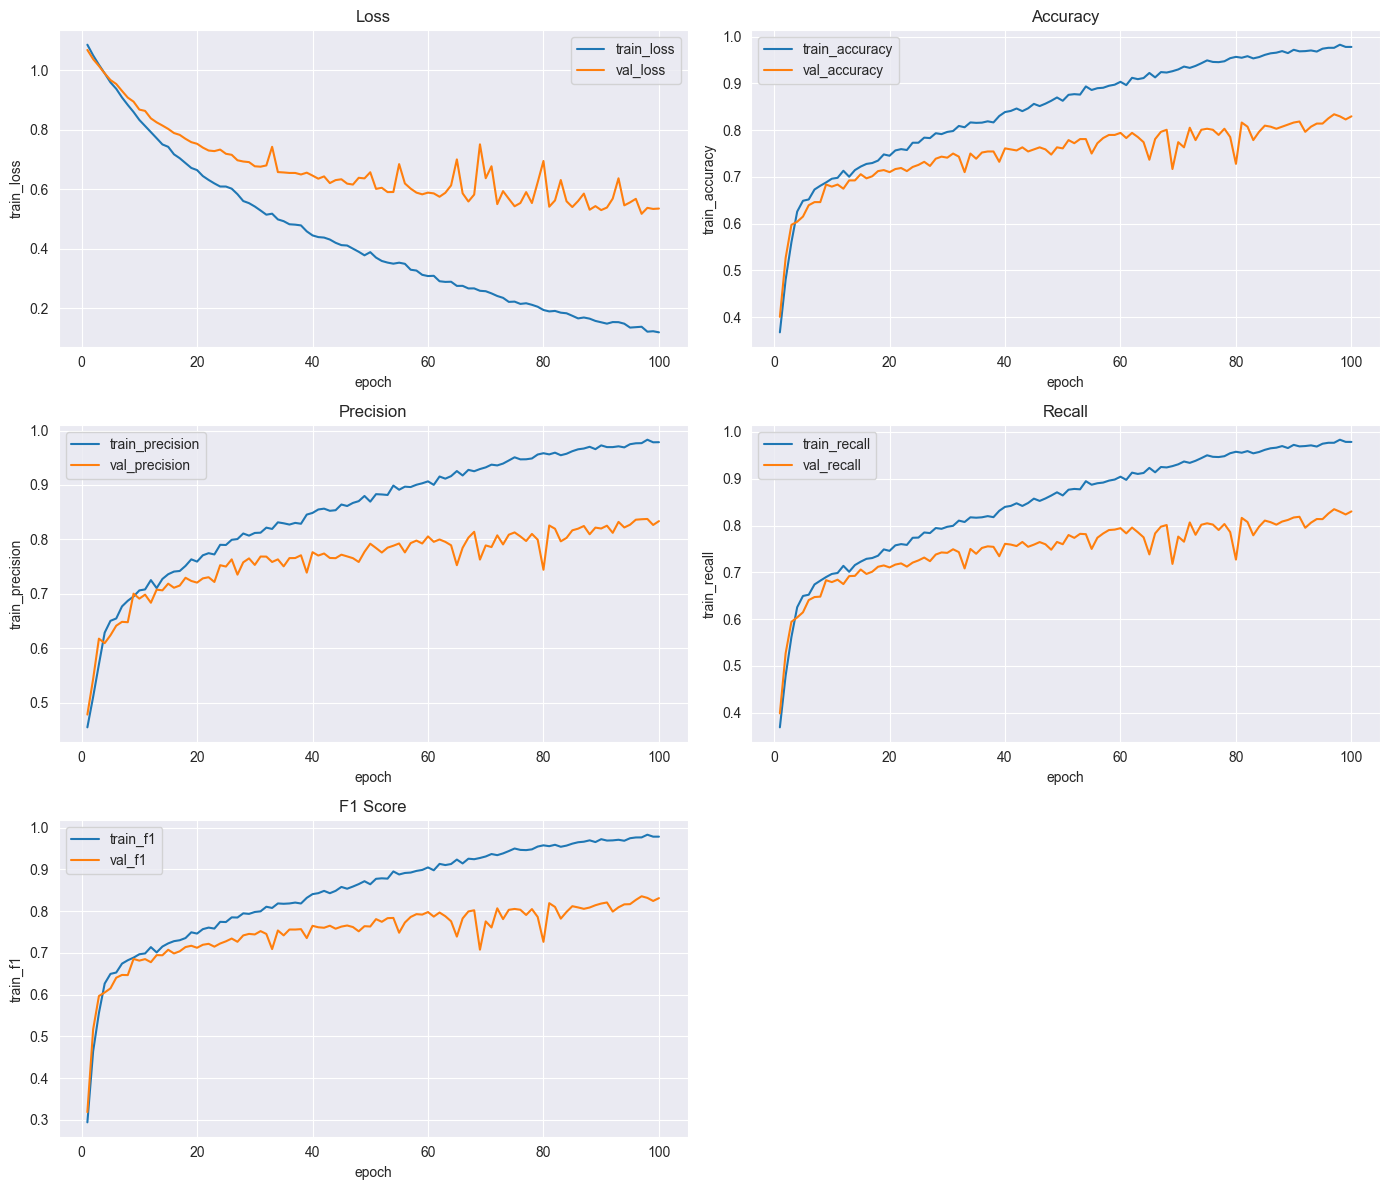

In [13]:
df = plot_training_metrics(history)
df.to_csv("../documentations/experiments/experiment4/tables/training_metrics.csv", index=False)

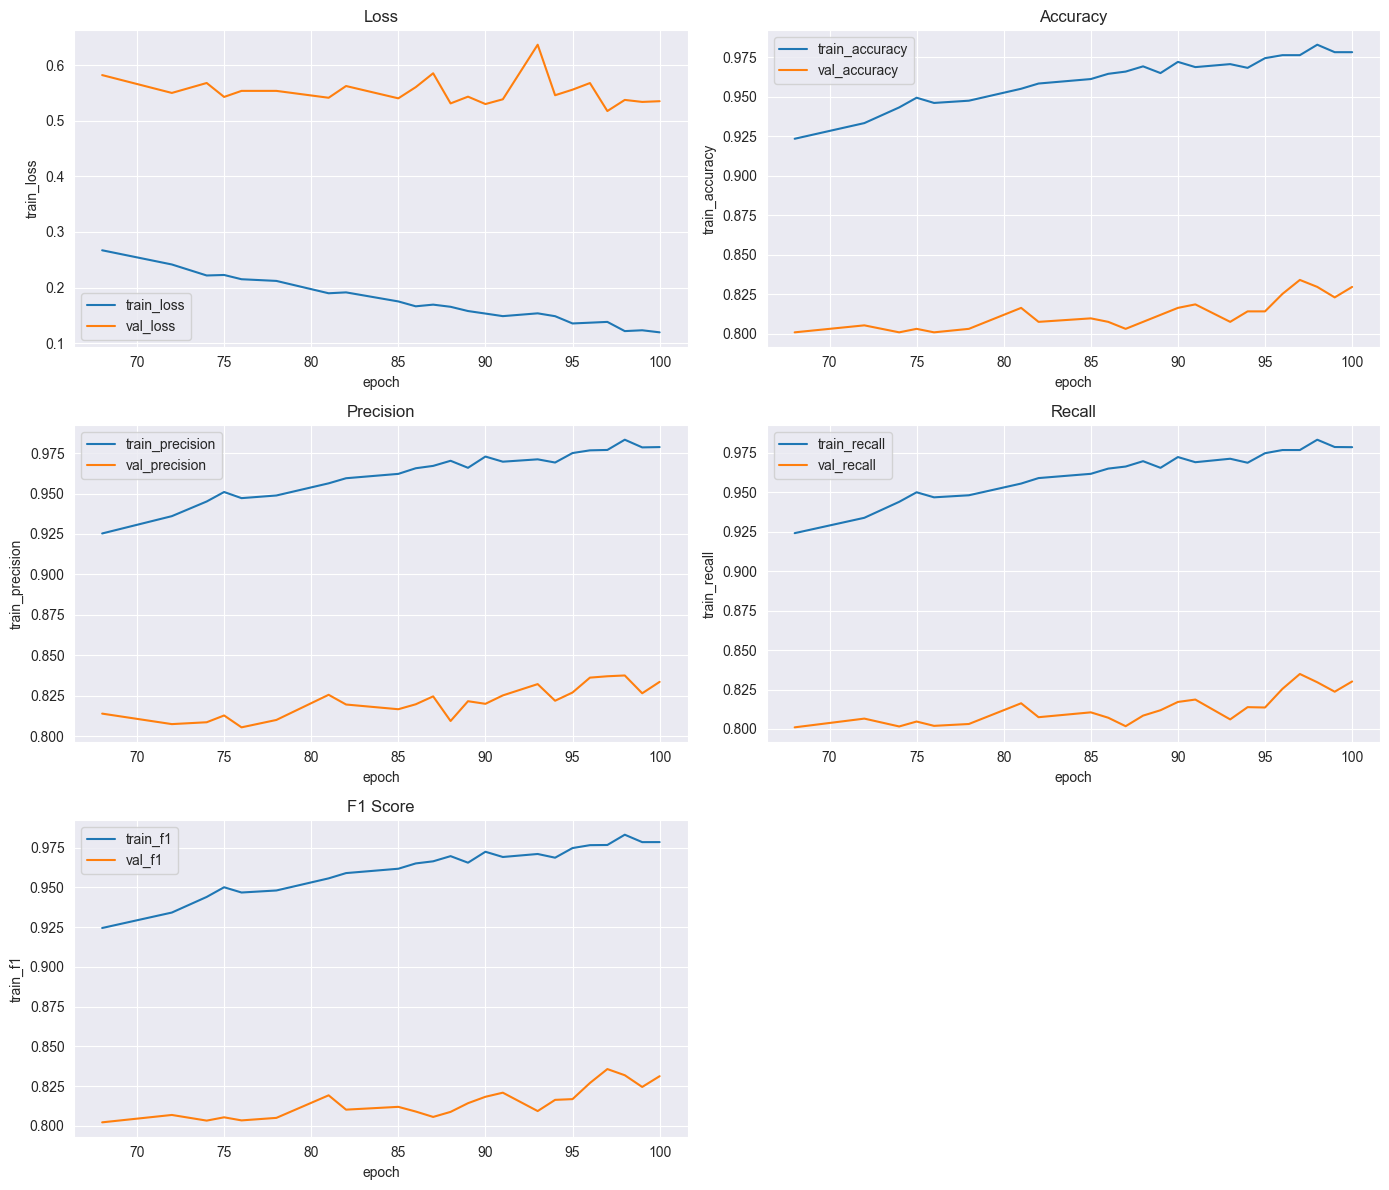

In [14]:
filtered_df = df[
    (df["val_accuracy"] >= 0.8) &
    (df["val_f1"] >= 0.8)
].to_dict()

high_accuracy_df = plot_training_metrics(filtered_df)

### Training/Validation Trend (100 epochs)
* Training loss consistently decreased from 1.0852 (epoch 1) to 0.1196 (epoch 100), showing continuous optimization and learning.
Training accuracy, precision, recall, and F1-score improved steadily, reaching above 97% after epoch 90, indicating strong fitting on the training data.
* Validation performance improved rapidly during early epochs, increasing from around 40% accuracy in epoch 1 to above 80% accuracy after epoch 70.
* Validation metrics showed fluctuations throughout training, with several drops after strong epochs, indicating some instability and possible overfitting tendency.
* The best validation improvement occurred around epochs 85–97, where validation accuracy, precision, recall, and F1 remained consistently high.
* After epoch 97, validation performance slightly decreased while training metrics continued increasing, suggesting the beginning of overfitting.
* No training metric reached 1.00, so no epoch needed to be rejected due to perfect training scores.
* The gap between training and validation performance increased in later epochs, showing that the model continued memorizing training patterns more than improving generalization.

The model learned effectively throughout training, with strong improvement in both training and validation metrics. The first 50 epochs showed consistent learning, while later epochs showed higher training accuracy but more unstable validation behaviour. Validation performance peaked near the end of training, but after epoch 97 the model started showing signs of overfitting because training metrics continued increasing while validation metrics declined. Epoch 97 provides the best balance between high validation performance and avoiding unnecessary additional fitting.

<b>Best Epoch 97</b>

<b>Loss</b>
* Train Loss = 0.1383646849
* Valid Loss = 0.5174597586

<b>Training Metrics</b>
* Train Accuracy = 0.9763705134
* Train Precison = 0.9769217968
* Train Recall = 0.9766728282
* Train F1 = 0.9767453074

<b>Validation Accuracy</b>
* Validation Accuracy = 0.8340708017
* Validation Precision = 0.8370292187
* Validation Recall = 0.8348357081
* Validation F1 = 0.8356957436

## Use Tester Module to Test Model

Load Model with State Dict

In [15]:
import copy

test_scores = []

# Transforms of Data
test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Dataset Loading From Image dir
test_dataset = datasets.ImageFolder(
    root="../datasets/fight-weaponized-other-dataset/test", 
    transform = test_transform 
    )

# DataLoader
test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=64,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
    )

# Loops for testing
for i in range(100):
    test_model = copy.deepcopy(model)

    checkpoint = torch.load(
        f"../models/experiment4/model_epoch_{i+1}.pt",
        map_location="cuda"
    )

    test_model.load_state_dict(checkpoint["model"])

    tester = Tester(
        test_model,
        test_loader,
        3,
        torch.nn.CrossEntropyLoss(),
        "cuda"
    )

    result = tester.test(return_predictions=True)

    test_scores.append(result)


### Save Test Metrics

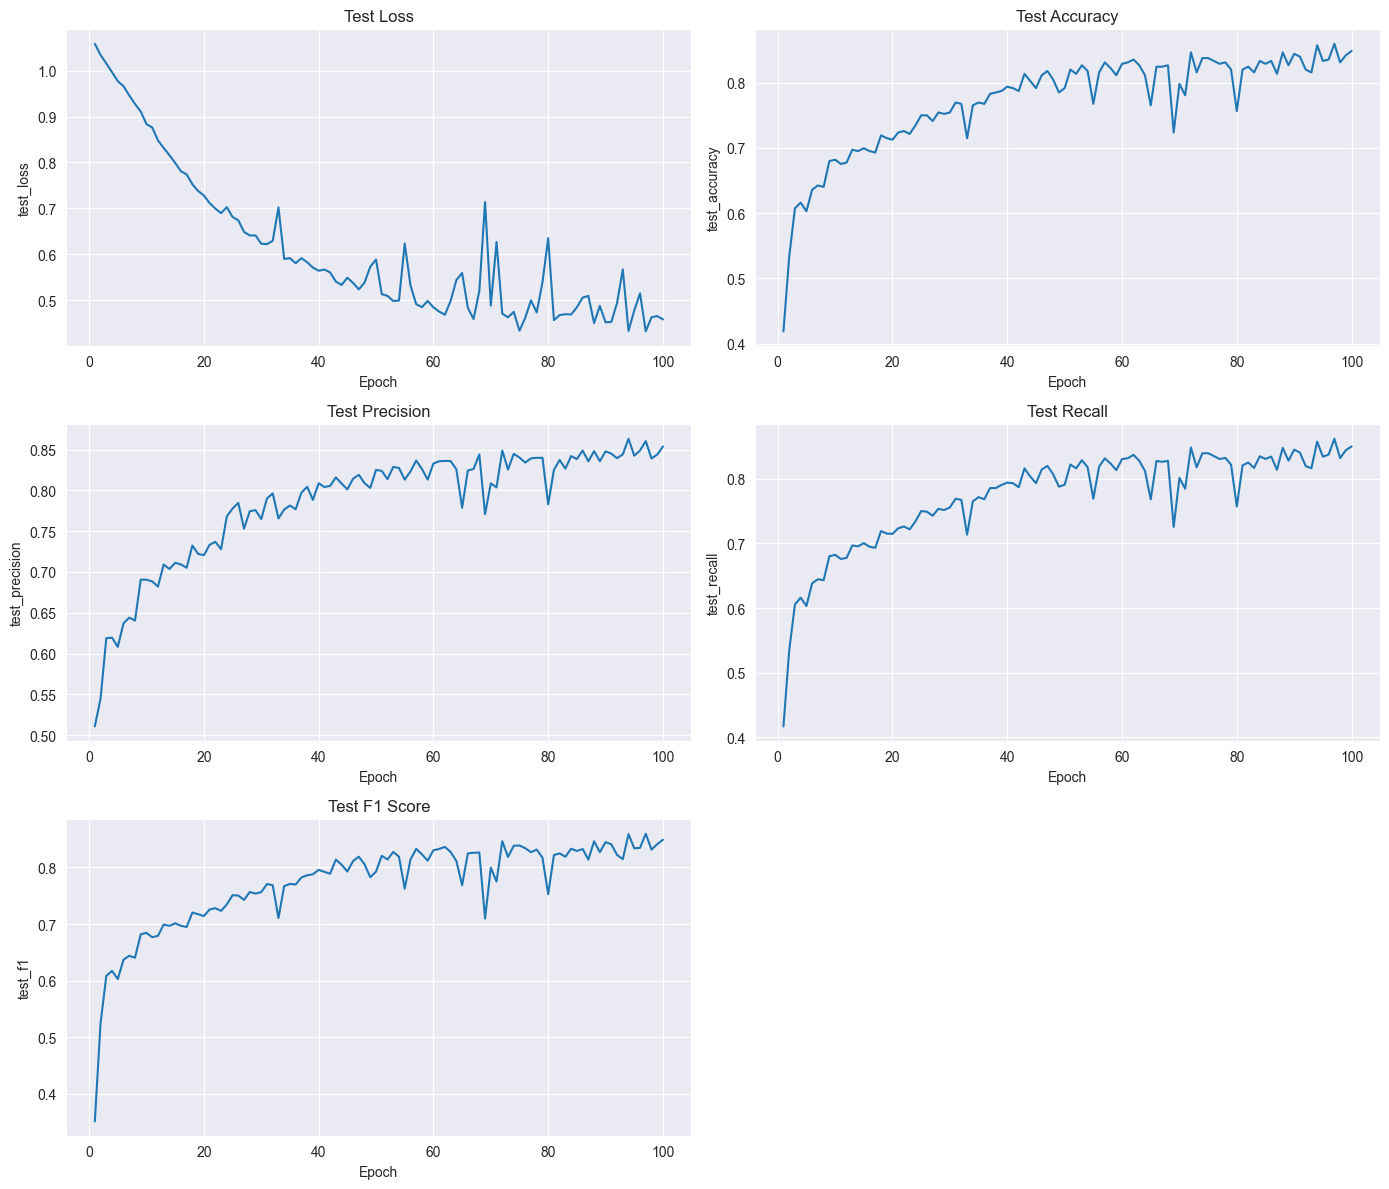

In [16]:
# Plot all 100 epochs
test_metrics_df = plot_testing_history(test_scores)
test_metrics_df.to_csv("../documentations/experiments/experiment4/tables/test_metrics.csv", index=False)

### Test Performance Trend (100 epochs)
* Test loss generally decreased from 1.0585 (epoch 1) to its lowest region around later epochs, showing continuous improvement in generalization.
* Test accuracy improved rapidly during early training, increasing from 41.89% (epoch 1) to above 80% after epoch 43.
* Test metrics (accuracy, precision, recall, F1) showed steady improvement until around epoch 60, followed by fluctuations.
* The model achieved its strongest test performance in the later training stage, especially between epochs 72–100.
* Test accuracy peaked multiple times, showing that validation/test behaviour was not strictly monotonic but remained stable at a high level.
* The best test accuracy was achieved at epoch 97 (85.96%), with strong precision, recall, and F1 values.
* Epoch 94 also performed strongly with 85.75% accuracy, but epoch 97 achieved better overall balance across accuracy, precision, recall, and F1.
* Test loss was lowest at epoch 97 among the highest-performing epochs, indicating better confidence and generalization compared with nearby epochs.
* After epoch 97, performance slightly fluctuated, but no significant degradation occurred, suggesting the model had reached convergence.

The test performance shows that the CNN learned useful features progressively, with major improvements occurring during the first 60 epochs. After this point, the model entered a stable convergence phase where test metrics fluctuated around high performance values rather than continuously increasing. The highest generalization performance was achieved near the end of training, with epoch 97 providing the best combination of accuracy, precision, recall, and F1-score. Unlike the training metrics, the test metrics did not show signs of overfitting because performance remained strong and stable.

<b>Best Epoch 97</b>

* Loss = 0.4317497499
* Accuracy = 0.8596491218
* Precision = 0.8603258133
* Recall = 0.8618202209
* F1-Score = 0.8597231507